# Day 3 셀프 수업 실습가이드

## 학습 목표

- `describe()`, `corr()`, `skew()` 결과를 읽고 기초 통계를 다시 설명해봐요.
- `histplot`, `boxplot`을 골라 써서 분포와 이상치를 같이 확인해봐요.
- `train_test_split`, `fit`, `predict`, `accuracy_score` 흐름을 손으로 다시 익혀봐요.
- KNN, Decision Tree, Random Forest 차이를 정확도 비교와 함께 말로 정리해봐요.
- Penguins 전처리부터 SVM 분류까지 한 번에 연결해보면서 Day 3 전체를 복습해봐요.

---

## 사용 데이터 안내

| 데이터 | 불러오는 방법 |
|---|---|
| Palmer Penguins | `seaborn.load_dataset("penguins")` |
| Iris | `sklearn.datasets.load_iris()` |

> 권장 실행 환경: Windows 11, Python 3.12, pandas 2.2.x, scikit-learn 1.6~1.7, seaborn 0.13.x

---

In [1]:
!pip install scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 3.9 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 3.0 MB/s  0:00:06m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

## 문제 1. \[쉬움\] Penguins 기초 통계 요약하고 상관계수 해석하기

### 문제 설명

Penguins 데이터에서 수치형 열만 골라 `describe()`와 `corr()` 결과를 확인해봐요.  
그다음 `body_mass_g`와 가장 강한 상관을 보이는 열이 무엇인지 찾아서 한 줄로 해석해보세요.  
마지막으로 수치형 열의 왜도도 같이 확인해서 분포 모양을 비교해보면 좋아요.

In [5]:
# TODO: Penguins 데이터를 불러와요.
df = pd.read_csv('../../data/Penguins.csv')

In [ ]:
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

In [6]:
# TODO: 수치형 열만 선택해요.
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [9]:
numeric_df = df.select_dtypes(include='number')
print(numeric_df.columns.to_list())

['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']


In [10]:
numeric_df = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]

describe() — 평균, 표준편차, 최솟값, 최댓값 등 기초 통계를 한눈에 확인해 데이터 분포와 이상값을 빠르게 파악합니다.

In [13]:
# TODO: describe() 결과를 출력해요.
numeric_df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


corr() — 변수 간 상관관계를 -1~1로 수치화해 어떤 feature가 타깃에 영향을 주는지 확인합니다.

In [16]:
# TODO: corr() 결과를 출력해요.
numeric_df.corr()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202
body_mass_g,0.595110,-0.471916,0.871202,1.000000


  skew() — 분포의 비대칭 정도를 확인해 정규화/로그 변환이 필요한 열을 찾습니다.

In [15]:
# TODO: skew() 결과를 출력해요.
numeric_df.skew()

bill_length_mm       0.053118
bill_depth_mm       -0.143465
flipper_length_mm    0.345682
body_mass_g          0.470329
dtype: float64


⏺ 상관계수는 두 변수가 얼마나 같이 움직이는지를 -1 ~ 1 사이 값으로 나타낸 수치입니다.

  ┌─────┬──────────────────────────────────┐
  │ 값  │               의미               │
  ├─────┼──────────────────────────────────┤
  │ 1   │ 완전한 양의 상관 (같이 증가)     │
  ├─────┼──────────────────────────────────┤
  │ -1  │ 완전한 음의 상관 (반대로 움직임) │
  ├─────┼──────────────────────────────────┤
  │ 0   │ 상관 없음                        │
  └─────┴──────────────────────────────────┘
  
  가장 좋은 값은 목적에 따라 다릅니다:
  - feature 선택 시 → 절댓값이 1에 가까울수록 타깃과 관련성이 높아 좋은 feature
  - 다중공선성 확인 시 → feature끼리 상관계수가 너무 높으면(|0.9| 이상) 오히려 모델에 안 좋음

In [17]:
# TODO: body_mass_g와 다른 수치형 열의 상관계수를 따로 확인해요.
numeric_df.corr()['body_mass_g']

bill_length_mm       0.595110
bill_depth_mm       -0.471916
flipper_length_mm    0.871202
body_mass_g          1.000000
Name: body_mass_g, dtype: float64

In [18]:
# TODO: 가장 상관이 큰 열 이름과 해석을 한 줄로 적어요.
corr_Series = numeric_df.corr()['body_mass_g'].drop('body_mass_g').abs()
print(corr_Series.idxmax(), corr_Series.max())

flipper_length_mm 0.8712017673060111


## 문제 2. \[보통\] Penguins 분포를 histplot과 boxplot으로 시각화하기

### 문제 설명

Penguins에서 `flipper_length_mm` 분포를 `histplot`으로 그리고,  
종별 `body_mass_g` 분포를 `boxplot`으로 비교해봐요.  
그래프 제목과 축 라벨은 한글로 넣고, 한글이 깨지지 않게 폰트 설정도 같이 해보세요.
### 힌트

- `plt.rcParams`, `sns.histplot()`, `sns.boxplot()` 정도만 떠올리면 돼요.
- `subplots()`으로 축 두 개를 한 번에 만들 수 있어요.


In [54]:
# TODO: Penguins 데이터를 불러와요.
df = pd.read_csv(r'../../data/Penguins.csv')

In [61]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [55]:
# TODO: matplotlib 한글 폰트를 설정해요.
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

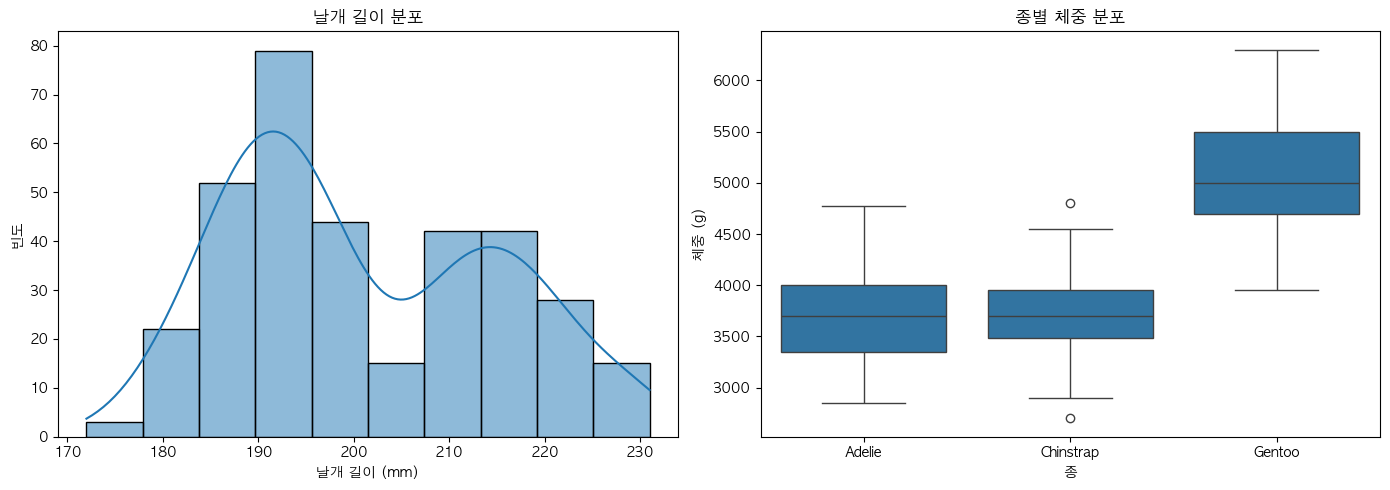

In [62]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="flipper_length_mm", kde=True, ax=ax1)
sns.boxplot(data=df, x="species", y="body_mass_g", ax=ax2)

ax1.set_title("날개 길이 분포")
ax1.set_xlabel("날개 길이 (mm)")
ax1.set_ylabel("빈도")

ax2.set_title("종별 체중 분포")
ax2.set_xlabel("종")
ax2.set_ylabel("체중 (g)")

plt.tight_layout()
plt.show()


## 문제 3. \[보통\] Iris로 KNN 분류 3줄 패턴 다시 쓰기

### 문제 설명

Iris 데이터를 불러와서 `train_test_split`으로 나누고,  
`KNeighborsClassifier(n_neighbors=5)`로 학습한 뒤 정확도를 확인해봐요.  
Day 3에서 배운 ML 3줄 패턴을 거의 그대로 다시 써보는 문제예요.
### 힌트

- `load_iris()`, `train_test_split()`, `fit()`, `predict()` 흐름이에요.
- 정확도 계산은 `accuracy_score()` 하나면 충분해요.

In [65]:
# TODO: load_iris()로 데이터와 타깃을 준비해요.
iris = load_iris()
X,y = iris.data , iris.target

In [67]:
# TODO: train_test_split()으로 훈련용과 테스트용을 나눠요.
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [68]:

# TODO: KNeighborsClassifier(n_neighbors=5) 모델을 만들어요.
model = KNeighborsClassifier(n_neighbors=6)
#새 데이터 예측시 가장 가까운 5개 이웃의 다수결로 클래스를 결정한다결정한다결정한다결정한다

In [69]:

# TODO: fit()으로 모델을 학습시켜요.
model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
# TODO: predict()로 예측값을 구해요.
y_pred = model.predict(X_test)
#테스트 데이터로 예측값을 구해 y_pred에 저장한다. 이후 y_test와 비교해 모델 성능을 평가한다.

In [ ]:
# TODO: accuracy_score()로 정확도를 출력해요.
accuracy_score(y_test, y_pred)
# y_test와 y_pred 각각 정답값, 예측값, 을 비교해 맞춘 비율을 0~1사이 값으로 반환한다반환한다

1.0


## 문제 4. \[어려움\] Iris에서 Decision Tree와 Random Forest 정확도 비교하기

### 문제 설명

문제 3에서 만든 같은 `X_train`, `X_test`, `y_train`, `y_test`를 그대로 재사용해요.  
이번에는 Decision Tree와 Random Forest를 각각 학습하고 정확도를 비교해보세요.  
어느 모델이 더 잘 나왔는지 한 줄 의견도 적어보면 좋아요.
### 힌트

- `DecisionTreeClassifier()`, `RandomForestClassifier()`를 나란히 쓰면 돼요.
- 핵심은 같은 train/test를 재사용해서 공정하게 비교하는 거예요.

In [ ]:
iris = load_iris()
X, y = 